In [1]:
import joblib
from ipywidgets import interact

import matplotlib.pyplot as plt

from pulearn import BaggingPuClassifier
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy import stats
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.base import clone
from sklearn.feature_selection import VarianceThreshold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

from lib.main import *

from parameters import parameters

In [2]:
columns_to_drop_deposit = parameters["columns_to_drop_deposit"]
columns_to_drop_unlabelled = parameters["columns_to_drop_unlabelled"]

outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]

deposit_data_filename = parameters["deposit_data_filename"]
unlabelled_data_filename = parameters["unlabelled_data_filename"]
target_data_filename = parameters["target_data_filename"]
features_imputed_weight_label_filename = parameters["features_imputed_weight_label_filename"]
corr_filename = parameters["corr_filename"]
Xy_train_original_filename = parameters["Xy_train_original_filename"]
Xy_pos_test_original_filename = parameters["Xy_pos_test_original_filename"]
Xy_train_filename = parameters["Xy_train_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
Xy_train_new_filename = parameters["Xy_train_new_filename"]

robust_scaler_filename = parameters["robust_scaler_filename"]
model_pub_filename = parameters["model_pub_filename"]

ml_dir = os.path.join(outputs_dir, ml_dir)
if not os.path.exists(ml_dir):
    os.makedirs(ml_dir, exist_ok=True)

deposit_data_filename = os.path.join(outputs_dir, deposit_data_filename)
unlabelled_data_filename = os.path.join(outputs_dir, unlabelled_data_filename)
target_data_filename = os.path.join(outputs_dir, target_data_filename)
features_imputed_weight_label_filename = os.path.join(outputs_dir, features_imputed_weight_label_filename)
corr_filename = os.path.join(outputs_dir, corr_filename)
Xy_train_original_filename = os.path.join(ml_dir, Xy_train_original_filename)
Xy_pos_test_original_filename = os.path.join(ml_dir, Xy_pos_test_original_filename)
Xy_train_filename = os.path.join(ml_dir, Xy_train_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)

robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)
model_pub_filename = os.path.join(ml_dir, model_pub_filename)

nprocs = 8

In [3]:
if os.path.isfile(features_imputed_weight_label_filename):
    features_imputed_weight_label = pd.read_csv(features_imputed_weight_label_filename)
else:
    deposit_data = pd.read_csv(deposit_data_filename)
    print('Number of deposits:', len(deposit_data))
    unlabelled_data = pd.read_csv(unlabelled_data_filename)

    deposit_data['label'] = 1
    unlabelled_data['label'] = 0

    deposit_labels = deposit_data['label']
    unlabelled_labels = unlabelled_data['label']
    
    deposit_weights = deposit_data['weight']
    unlabelled_weights = unlabelled_data['weight']

    unlabelled_data_sampled = downsample_unlabelled(deposit_data, unlabelled_data, random_state=42, multiplier=10)
    print('Number of unlabelled samples:', len(unlabelled_data_sampled))

    deposit_features = deposit_data.drop(columns=columns_to_drop_deposit)
    unlabelled_features_sampled = unlabelled_data_sampled.drop(columns=columns_to_drop_unlabelled)
    features_sampled = pd.concat([deposit_features, unlabelled_features_sampled], ignore_index=True)
    labels = pd.concat([deposit_labels, unlabelled_labels], ignore_index=True)
    weights = pd.concat([deposit_weights, unlabelled_weights], ignore_index=True)
    
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(random_state=42),
        random_state=42,
    )
    features_imputed_array = imputer.fit_transform(features_sampled)

    features_imputed = pd.DataFrame(features_imputed_array, columns=features_sampled.columns)
    features_imputed_weight_label = features_imputed.copy()
    features_imputed_weight_label['weight'] = weights
    features_imputed_weight_label['label'] = labels
    features_imputed_weight_label.to_csv(features_imputed_weight_label_filename, index=False)

features_imputed = features_imputed_weight_label.drop(['weight', 'label'], axis=1)

### Correlation

In [4]:
if os.path.isfile(corr_filename):
    corr = pd.read_csv(corr_filename, index_col=0)
else:
    corr = features_imputed.corr(method='spearman').round(3)
    corr.to_csv(corr_filename, index=True)
    
correlations = analyze_correlations(corr, threshold=0.8)
generate_report(correlations, threshold=0.8)

Correlation Analysis Report (Threshold: 0.8)

Feature: convergence_rate (cm/yr)
------------------------------
Positive Correlations:
  convergence_rate_orthogonal (cm/yr): 0.924
  water_flux (m^2/yr): 0.876
  slab_flux (m^2/yr): 0.852

Feature: slab_dip (degrees)
------------------------------
Negative Correlations:
  arc_trench_distance (km): -1.000

Feature: sedimentary_bound_water_thickness (m)
------------------------------
Positive Correlations:
  sedimentary_pore_water_thickness (m): 1.000
  sediment_thickness (m): 1.000
  total_water_thickness (m): 0.898

Feature: sedimentary_pore_water_thickness (m)
------------------------------
Positive Correlations:
  sedimentary_bound_water_thickness (m): 1.000
  sediment_thickness (m): 1.000
  total_water_thickness (m): 0.898

Feature: carbonate_carbon_density (t/m^2)
------------------------------
Positive Correlations:
  carbonate_thickness (m): 1.000
  subducted_carbonate_volume (m): 0.902

Feature: trench_velocity (cm/yr)
------------

### Dendrogram

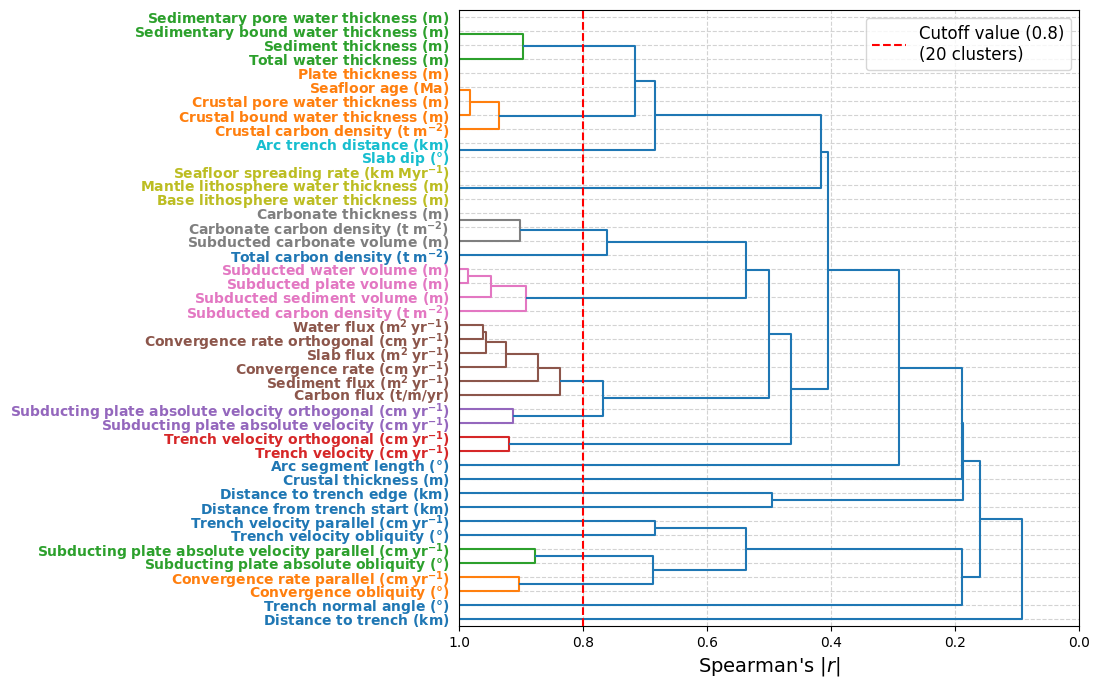

In [5]:
cutoff_value = 0.8
cluster_threshold = 1 - cutoff_value

Z = linkage(
    features_imputed.T,
    method="single",
    metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
)

cluster_ids = fcluster(Z, cluster_threshold, criterion="distance")
clusters = {
    cluster_id: list(features_imputed.columns[cluster_ids == cluster_id])
    for cluster_id in np.unique(cluster_ids)
}

fig, ax = plt.subplots(figsize=(8, 8))
dendro = dendrogram(
    Z,
    orientation="right",
    labels=[format_feature_name(i, bold=True) for i in features_imputed.columns],
    ax=ax,
    color_threshold=cluster_threshold,
)
ax.axvline(
    cluster_threshold,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} clusters)",
)
ax.grid(linestyle="dashed", color="lightgrey")
ax.set_xticks(ax.get_xticks(), [f"{1 - i:0.1f}" for i in ax.get_xticks()])
ax.set_xlabel(r"Spearman's $|r|$", fontsize=14)
ax.tick_params(labelsize=10)
for i, j in zip(ax.get_ymajorticklabels(), dendro["leaves_color_list"]):
    i.set_color(j)
    i.set_fontweight("bold")
ax.legend(loc="best", fontsize=12)

In [6]:
for cluster_id in sorted(clusters.keys()):
    cluster_features = clusters[cluster_id]
    print(f"Cluster #{cluster_id}:")
    for feature in cluster_features:
        print(f"  - {feature}")

Cluster #1:
  - convergence_obliquity (degrees)
  - convergence_rate_parallel (cm/yr)
Cluster #2:
  - subducting_plate_absolute_obliquity (degrees)
  - subducting_plate_absolute_velocity_parallel (cm/yr)
Cluster #3:
  - trench_velocity_obliquity (degrees)
Cluster #4:
  - trench_velocity_parallel (cm/yr)
Cluster #5:
  - trench_normal_angle (degrees)
Cluster #6:
  - distance_from_trench_start (km)
Cluster #7:
  - distance_to_trench_edge (km)
Cluster #8:
  - trench_velocity (cm/yr)
  - trench_velocity_orthogonal (cm/yr)
Cluster #9:
  - subducting_plate_absolute_velocity (cm/yr)
  - subducting_plate_absolute_velocity_orthogonal (cm/yr)
Cluster #10:
  - convergence_rate (cm/yr)
  - carbon_flux (t/m/yr)
  - convergence_rate_orthogonal (cm/yr)
  - sediment_flux (m^2/yr)
  - slab_flux (m^2/yr)
  - water_flux (m^2/yr)
Cluster #11:
  - subducted_plate_volume (m)
  - subducted_water_volume (m)
  - subducted_carbon_density (t/m^2)
  - subducted_sediment_volume (m)
Cluster #12:
  - carbonate_carbon

Text(0, 0.5, 'Number of remaining features')

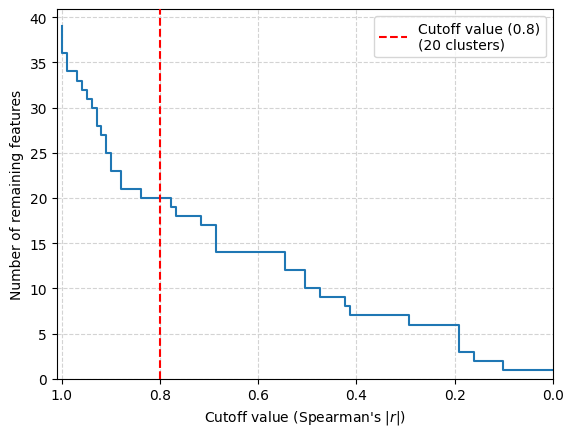

In [7]:
thresh_vals = np.linspace(0, 1, 100)
thresh_clusters = np.array([
    len(np.unique(fcluster(Z, 1 - t, criterion="distance")))
    for t in thresh_vals
])

fig, ax = plt.subplots()
ax.step(thresh_vals, thresh_clusters, where="post")
ax.axvline(
    cutoff_value,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} clusters)",
)
ax.set_xlim(thresh_vals.max() * 1.01, thresh_vals.min())
ax.set_ylim(0, None)
ax.grid(linestyle="dashed", color="lightgrey")
ax.legend(loc="best")
ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
ax.set_ylabel("Number of remaining features")

### Selected Features

In [8]:
selected_features = [
    "arc_segment_length (degrees)",
#     "arc_trench_distance (km)",
#     "base_lithosphere_water_thickness (m)",
#     "carbon_flux (t/m/yr)",
#     "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "convergence_obliquity (degrees)",
#     "convergence_rate (cm/yr)",
#     "convergence_rate_orthogonal (cm/yr)",
#     "convergence_rate_parallel (cm/yr)",
#     "crustal_bound_water_thickness (m)",
#     "crustal_carbon_density (t/m^2)",
#     "crustal_pore_water_thickness (m)",
    "crustal_thickness (m)",
    "distance_from_trench_start (km)",
    "distance_to_trench (km)",
    "distance_to_trench_edge (km)",
#     "mantle_lithosphere_water_thickness (m)",
#     "plate_thickness (m)",
    "seafloor_age (Ma)",
    "seafloor_spreading_rate (km/Myr)",
#     "sediment_flux (m^2/yr)",
    "sediment_thickness (m)",
#     "sedimentary_bound_water_thickness (m)",
#     "sedimentary_pore_water_thickness (m)",
    "slab_dip (degrees)",
    "slab_flux (m^2/yr)",
#     "subducted_carbon_density (t/m^2)",
#     "subducted_carbonate_volume (m)",
#     "subducted_plate_volume (m)",
    "subducted_sediment_volume (m)",
#     "subducted_water_volume (m)",
    "subducting_plate_absolute_obliquity (degrees)",
#     "subducting_plate_absolute_velocity (cm/yr)",
    "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
#     "subducting_plate_absolute_velocity_parallel (cm/yr)",
    "total_carbon_density (t/m^2)",
#     "total_water_thickness (m)",
    "trench_normal_angle (degrees)",
#     "trench_velocity (cm/yr)",
    "trench_velocity_obliquity (degrees)",
    "trench_velocity_orthogonal (cm/yr)",
    "trench_velocity_parallel (cm/yr)",
#     "water_flux (m^2/yr)",
]

### Train-Test Split

In [9]:
selected_features_weight = selected_features.copy()
selected_features_weight.append('weight')

if os.path.isfile(robust_scaler_filename):
    robust_scaler = joblib.load(robust_scaler_filename)
    Xy_train_original = pd.read_csv(Xy_train_original_filename)
    Xy_train = pd.read_csv(Xy_train_filename)
    Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
else:
    deposit_features_imputed_weight_label = features_imputed_weight_label[features_imputed_weight_label['label'] == 1]
    unlabelled_features_imputed_weight_label = features_imputed_weight_label[features_imputed_weight_label['label'] == 0]

    deposit_features_imputed_weight = deposit_features_imputed_weight_label[selected_features_weight]
    unlabelled_features_imputed_weight = unlabelled_features_imputed_weight_label[selected_features_weight]

    deposit_labels = deposit_features_imputed_weight_label['label']
    unlabelled_labels = unlabelled_features_imputed_weight_label['label']

    # split positive samples into train and test datasets
    X_pos_train, X_pos_test, y_pos_train, y_pos_test = train_test_split(deposit_features_imputed_weight, deposit_labels, train_size=0.8, random_state=42)
    X_train = np.vstack((X_pos_train, unlabelled_features_imputed_weight))
    y_train = np.vstack((y_pos_train.values.reshape(-1, 1), unlabelled_labels.values.reshape(-1, 1)))

    selected_features_weight_label = selected_features_weight.copy()
    selected_features_weight_label.append('label')

    Xy_train_original = np.hstack((X_train, y_train))
    Xy_train_original = pd.DataFrame(Xy_train_original, columns=selected_features_weight_label)
    Xy_train_original.to_csv(Xy_train_original_filename, index=False)

    Xy_train_features = Xy_train_original[selected_features]
    Xy_train_labels = Xy_train_original['label']
    Xy_train_weights = Xy_train_original['weight']

    robust_scaler = RobustScaler()
    X_train = robust_scaler.fit_transform(Xy_train_features)
    Xy_train = np.hstack((X_train, Xy_train_weights.values.reshape(-1, 1), Xy_train_labels.values.reshape(-1, 1)))
    Xy_train = pd.DataFrame(Xy_train, columns=selected_features_weight_label)
    Xy_train.to_csv(Xy_train_filename, index=False)

    Xy_pos_test_original = np.hstack((X_pos_test, y_pos_test.values.reshape(-1, 1)))
    Xy_pos_test_original = pd.DataFrame(Xy_pos_test_original, columns=selected_features_weight_label)
    Xy_pos_test_original.to_csv(Xy_pos_test_original_filename, index=False)

    Xy_pos_test_features = Xy_pos_test_original[selected_features]
    Xy_pos_test_labels = Xy_pos_test_original['label']
    Xy_pos_test_weights = Xy_pos_test_original['weight']

    X_pos_test = robust_scaler.transform(Xy_pos_test_features)
    Xy_pos_test = np.hstack((X_pos_test, Xy_pos_test_weights.values.reshape(-1, 1), Xy_pos_test_labels.values.reshape(-1, 1)))
    Xy_pos_test = pd.DataFrame(Xy_pos_test, columns=selected_features_weight_label)
    Xy_pos_test.to_csv(Xy_pos_test_filename, index=False)

    joblib.dump(robust_scaler, robust_scaler_filename)
    
    print('Number of positive training samples:', X_pos_train.shape[0])
    print('Number of unlabelled training samples:', unlabelled_features_imputed_weight.shape[0])
    print('Number of positive testing samples:', X_pos_test.shape[0])

### Positive and Unlabelled Bagging

In [10]:
features_pub = Xy_train[[col for col in Xy_train.columns if col not in ['weight', 'label']]]
labels_pub = Xy_train['label']
weights_pub = Xy_train['weight']

if os.path.isfile(model_pub_filename):
    model_pub = joblib.load(model_pub_filename)
else:
    # Random Forest model structure
    rf_pub = RandomForestClassifier(n_jobs=nprocs, random_state=42)
    pub = BaggingPuClassifier(rf_pub, n_jobs=nprocs, random_state=42)

    n_fold = 10

    search_space = {
    'estimator__bootstrap': Categorical([True, False]),
    'estimator__max_depth': Integer(5, 20),
    'estimator__max_features': Categorical([None, 'sqrt','log2']), 
    'estimator__min_samples_leaf': Integer(2, 20),
    'estimator__min_samples_split': Integer(2, 30),
    'estimator__n_estimators': Integer(10, 200),
#     'base_estimator__bootstrap': Categorical([True, False]),
#     'base_estimator__max_depth': Integer(5, 20),
#     'base_estimator__max_features': Categorical([None, 'sqrt','log2']), 
#     'base_estimator__min_samples_leaf': Integer(2, 20),
#     'base_estimator__min_samples_split': Integer(2, 30),
#     'base_estimator__n_estimators': Integer(10, 200),
    'max_samples': Integer(int(0.5*(len(labels_pub)-sum(labels_pub))), int(0.9*(len(labels_pub)-sum(labels_pub))))
    }

    pub_bayes_search = BayesSearchCV(pub,
                                     search_space,
                                     n_iter=50, # specify how many iterations
                                     scoring='f1',
                                     n_jobs=nprocs,
                                     cv=n_fold,
                                     verbose=1,
                                     random_state=42)
    pub_bayes_search.fit(features_pub, labels_pub, sample_weight=weights_pub)
    
    # Extract the optimization results
    optimization_results = pub_bayes_search.cv_results_['mean_test_score']
    
    model_pub = pub_bayes_search.best_estimator_
    model_pub_f1 = pub_bayes_search.best_score_    
    print('The highest F1-score during cross validation:', model_pub_f1)
    
    # Save the model
    joblib.dump(model_pub, model_pub_filename)
    
    # Plot the Bayesian optimization progress
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(optimization_results) + 1), optimization_results, marker='o', color='black', markerfacecolor='red')
    plt.xlim(0, len(optimization_results) + 1)
    plt.xlabel('Bayesian Optimization Iteration')
    plt.ylabel('Mean Test F1 Score')
    plt.title('Bayesian Optimization Progress')
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    # plt.savefig(...)
    plt.show()

In [11]:
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ['weight', 'label']]]
y_pos_test = Xy_pos_test['label']
weights_pos_test = Xy_pos_test['weight']
X_pos_pred = model_pub.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print('Accuracy:', X_pos_pred_acc)

Accuracy: 0.7777777777777778


In [12]:
if os.path.isfile(Xy_train_new_filename):
    Xy_train_new = pd.read_csv(Xy_train_new_filename)
else:
    labels_pred = model_pub.predict(features_pub)
    
    labels_new = []
    for real, pred in zip(labels_pub, labels_pred):
        if real == 1:
            labels_new.append(1)
        elif pred == 1:
            labels_new.append(2)
        else:
            labels_new.append(0)

    Xy_train_new = features_pub.copy()
    Xy_train_new['weight'] = weights_pub
    Xy_train_new['label'] = labels_new
    Xy_train_new.to_csv(Xy_train_new_filename, index=False)

### Histogram

In [13]:
Xy_train_new_filtered = Xy_train_new[Xy_train_new['label'] != 2]
Xy_train_original_filtered = Xy_train_original[Xy_train_original['label'] != 2]

@interact
def show_hist(feature=selected_features):
    fig = plt.figure(figsize=(4, 4))
    ax1 = fig.add_subplot(111)
    ax1.set_facecolor('whitesmoke')
    ax2 = ax1.twiny()
    ax3 = ax2.twinx()
    
    # Calculate bin edges based on the entire dataset
    min_val = Xy_train_new_filtered[feature].min()
    max_val = Xy_train_new_filtered[feature].max()
    bin_edges = np.linspace(min_val, max_val, 26)  # 25 bins, 26 edges
    # conv_angle_deg
#     bin_edges = np.linspace(min_val, max_val, 51)  # 25 bins, 26 edges
    
    # Histogram for original data (transparent)
    ax1.hist(Xy_train_original_filtered[feature], bins=25, alpha=0.0)
    # conv_angle_deg
#     ax1.hist(Xy_train_original[feature], bins=50, alpha=0.0)
    
    # Histograms for standardized data with black edges and consistent bin widths
    h1 = ax2.hist(Xy_train_new_filtered.loc[Xy_train_new_filtered['label']==0][feature], bins=bin_edges, 
                  color='LightSalmon', label='Negative', 
                  edgecolor='black', linewidth=1)
    h2 = ax2.hist(Xy_train_new_filtered.loc[Xy_train_new_filtered['label']==1][feature], bins=bin_edges, 
                  color='DarkSeaGreen', label='Positive', alpha=0.8, 
                  edgecolor='black', linewidth=1)
    
    kde_x = np.linspace(min_val, max_val, 100)
    
    kde1 = stats.gaussian_kde(Xy_train_new_filtered.loc[Xy_train_new_filtered['label']==0][feature])
    kde2 = stats.gaussian_kde(Xy_train_new_filtered.loc[Xy_train_new_filtered['label']==1][feature])
    
    k1 = ax3.plot(kde_x, kde1(kde_x), color='LightSalmon')
    k2 = ax3.plot(kde_x, kde2(kde_x), color='DarkSeaGreen')
    
    # Calculate maximum values for y-axes
    max_freq = max(np.max(h1[0]), np.max(h2[0]))
    max_density = max(np.max(kde1(kde_x)), np.max(kde2(kde_x)))
    
    # Set y-axis limits with some padding
    ax2.set_ylim(0, max_freq * 1.1)
    ax3.set_ylim(0, max_density * 1.1)
    
    # Adjust tick locations for both y-axes
    ax2.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax3.yaxis.set_major_locator(plt.MaxNLocator(5))
    
    ax2.legend(loc='best')
    
    ax1.set_xlabel(feature + '\n(Actual)')
    # conv_angle_deg
#     ax1.set_xlabel('Obliquity angle of the relative motion vector (deg)')
    ax2.set_xlabel(feature + '\n(Scaled)')
    # conv_angle_deg
#     ax2.set_xlabel('Obliquity angle of the relative motion vector (Standardised)')
    ax1.set_ylabel('Frequency')
    ax3.set_ylabel('Probability density')
    
    # conv_angle_deg
#     ax1.set_xlim(-90, 90)
#     ax2.set_xlim(-2.5, 1)

#     plt.savefig(
#         f'./figures/muller2019/histograms/conv_angle_deg_edited.png',
#         bbox_inches='tight',
#         pad_inches=0.1,
#         dpi=150
#     )
    
    plt.show()

interactive(children=(Dropdown(description='feature', options=('arc_segment_length (degrees)', 'carbonate_thic…

### Violin-Box Plot

In [14]:
# Pivot dataframes
Xy_train_pivot = Xy_train_new_filtered.pivot(columns=['label'])
Xy_train_original_pivot = Xy_train_original_filtered.pivot(columns=['label'])
nb_groups1 = Xy_train_new_filtered['label'].nunique()
nb_groups2 = Xy_train_original_filtered['label'].nunique()

@interact
def show_violin_box(feature=selected_features):    
    # Prepare data
    plot_data1 = [Xy_train_pivot[feature][var].dropna() for var in Xy_train_pivot[feature]]
    plot_data2 = [Xy_train_original_pivot[feature][var].dropna() for var in Xy_train_original_pivot[feature]]
    
    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax1.set_facecolor('whitesmoke')
    
    # Define colors
    colors = ['LightSalmon', 'DarkSeaGreen']
    
    # Create violin plots first (semi-transparent)
    vplot1_parts = ax1.violinplot(plot_data1, positions=np.arange(nb_groups1))
    
    # Style violin plots
    for i, body in enumerate(vplot1_parts['bodies']):
        body.set_facecolor(colors[i])
        body.set_edgecolor(colors[i])
        
    vplot1_parts['cbars'].set_edgecolor('black')
    vplot1_parts['cmins'].set_edgecolor('black')
    vplot1_parts['cmaxes'].set_edgecolor('black')
    
    # Create box plots on top with gray whiskers and no caps
    bp1 = ax1.boxplot(plot_data1, positions=np.arange(nb_groups1), patch_artist=True,
                      whis=(5, 95), widths=0.2,
                      flierprops=dict(marker='.', markersize=8, markerfacecolor='red', markeredgecolor='black', fillstyle=None),
                      medianprops=dict(color='black', linewidth=1.5),
                      whiskerprops=dict(color='black', linestyle='-'),  # Gray whiskers
                      capprops=dict(visible=False))  # Remove whisker caps
    
    # Color the boxes
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
    
    # Create transparent box plots for original data
    ax2 = ax1.twinx()
    box_param2 = dict(whis=(5, 95), widths=0, patch_artist=True,
                     flierprops=dict(marker='.', markeredgecolor='none', fillstyle=None),
                     medianprops=dict(color='none'), whiskerprops=dict(color='none'),
                     boxprops=dict(facecolor='none', edgecolor='none'))
    ax2.boxplot(plot_data2, positions=np.arange(nb_groups2), **box_param2)
        
    # Format axes
    ax1.set_xticks(np.arange(nb_groups1))
    ax1.set_xticklabels(['Negative', 'Positive'])
    ax1.tick_params(axis='x')
    ax1.tick_params(axis='y')
    ax2.tick_params(axis='y')
    
    # Format labels
    ax1.set_ylabel(feature + '\n(Standardised)')
    ax2.set_ylabel(feature + '\n(Actual)')
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('arc_segment_length (degrees)', 'carbonate_thic…